In [1]:
# =====================================================
# DATA PREPARATION PHASE
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

import os

# Styling
plt.style.use('seaborn-v0_8')

sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['font.size'] = 12

print("🧹 DATA PREPARATION PHASE")
print("="*60)

🧹 DATA PREPARATION PHASE


In [2]:
print("\n📂 LOADING DATASET")
print("="*50)

df = pd.read_excel(
    "../dataset/raw/emdat-country-profiles_idn_2026_05_23.xlsx"
)

# Hapus baris metadata EM-DAT
df = df.iloc[1:].reset_index(drop=True)

print("✅ Dataset loaded successfully!")
print(f"📊 Shape Dataset : {df.shape}")

display(df.head())


📂 LOADING DATASET
✅ Dataset loaded successfully!
📊 Shape Dataset : (158, 13)


,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,2000,Indonesia,IDN,Natural,Climatological,Wildfire,Forest fire,1,NaN,NaN,NaN,NaN,53.487737
1,2000,Indonesia,IDN,Natural,Geophysical,Earthquake,Ground movement,5,270108,149,73000000.0,136479882,53.487737
2,2000,Indonesia,IDN,Natural,Hydrological,Flood,Flash flood,2,89852,164,79000000.0,147697407,53.487737
3,2000,Indonesia,IDN,Natural,Hydrological,Flood,Riverine flood,1,386021,100,34000000.0,63565973,53.487737
4,2000,Indonesia,IDN,Natural,Hydrological,Mass movement (wet),Landslide (wet),2,539,52,NaN,NaN,53.487737


In [3]:
print("\n🔧 Handling Missing Values...")
print("="*50)

numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    df[col].fillna(
        df[col].median(),
        inplace=True
    )

print(
    f"Remaining Missing Values : {df.isnull().sum().sum()}"
)

print("✅ Missing values handled successfully!")


🔧 Handling Missing Values...
Remaining Missing Values : 250
✅ Missing values handled successfully!


In [4]:
print("\n🔧 Removing Duplicate...")
print("="*50)

df.drop_duplicates(
    inplace=True
)

print(
    f"Remaining Duplicate Rows : {df.duplicated().sum()}"
)

print("✅ Duplicate records removed!")


🔧 Removing Duplicate...
Remaining Duplicate Rows : 0
✅ Duplicate records removed!


In [5]:
print("\n🔧 Removing Outlier...")
print("="*50)

print("\n💡 INSIGHT")

print("""
Outlier ditemukan pada beberapa variabel seperti
Total Deaths dan Total Damage.

Karena dataset bencana memang memiliki kejadian
ekstrem yang penting secara historis,
outlier tidak akan dihapus.
""")


🔧 Removing Outlier...

💡 INSIGHT

Outlier ditemukan pada beberapa variabel seperti
Total Deaths dan Total Damage.

Karena dataset bencana memang memiliki kejadian
ekstrem yang penting secara historis,
outlier tidak akan dihapus.



In [7]:
print("\n⚖️ FEATURE SELECTION")
print("="*50)

features = [

    'Total Events',

    'Total Deaths',

    'Total Affected',

    'Total Damage (USD, original)'

]

X = df[features]

# Statistik Fitur
display(
    X.describe()
)


⚖️ FEATURE SELECTION


,"Total Damage (USD, original)"
count,5.600000e+01
mean,4.917235e+08
std,1.004762e+09
min,1.000000e+06
25%,1.800000e+07
50%,6.100000e+07
75%,2.754000e+08
max,4.451600e+09


In [12]:
# =====================================================
# 📏 DATA STANDARDIZATION
# =====================================================

print("\n📏 DATA STANDARDIZATION")
print("=" * 50)

# Salin data fitur
X_scaled_input = X.copy()

# -----------------------------------------------------
# Cek Missing Values
# -----------------------------------------------------

print("\n🔍 Missing Values Before Scaling")

missing_before = X_scaled_input.isnull().sum()

display(
    missing_before[missing_before > 0]
)

# -----------------------------------------------------
# Handle Missing Values
# -----------------------------------------------------

for col in X_scaled_input.columns:

    X_scaled_input[col] = pd.to_numeric(
        X_scaled_input[col],
        errors="coerce"
    )

    X_scaled_input[col] = X_scaled_input[col].fillna(
        X_scaled_input[col].median()
    )

print("\n✅ Missing values successfully handled")

# -----------------------------------------------------
# Standardization
# -----------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_scaled_input
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

# -----------------------------------------------------
# Validation
# -----------------------------------------------------

print("\n📊 Scaled Dataset Preview")

display(
    X_scaled.head()
)

print("\n📋 Scaling Statistics")

stats_df = pd.DataFrame({
    "Mean": X_scaled.mean().round(4),
    "Std": X_scaled.std().round(4)
})

display(stats_df)

print("\n🔍 Missing Values After Scaling")

print(
    X_scaled.isnull().sum().sum()
)

print("""
✅ Standardization Completed Successfully

📌 Mean ≈ 0
📌 Standard Deviation ≈ 1
📌 No Missing Values Remaining
""")


📏 DATA STANDARDIZATION

🔍 Missing Values Before Scaling


Total Deaths                     31
Total Affected                    9
Total Damage (USD, original)    102
dtype: int64


✅ Missing values successfully handled

📊 Scaled Dataset Preview


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)"
0,-0.638565,-0.088664,-0.183566,-0.243249
1,0.937892,-0.080750,-0.018135,-0.224128
2,-0.244451,-0.079608,-0.134117,-0.214568
3,-0.638565,-0.084478,0.056447,-0.286270
4,-0.244451,-0.088131,-0.191584,-0.243249



📋 Scaling Statistics


,Mean,Std
Total Events,-0.0,1.0032
Total Deaths,-0.0,1.0032
Total Affected,-0.0,1.0032
"Total Damage (USD, original)",0.0,1.0032



🔍 Missing Values After Scaling
0

✅ Standardization Completed Successfully

📌 Mean ≈ 0
📌 Standard Deviation ≈ 1
📌 No Missing Values Remaining




📉 PCA DIMENSIONALITY REDUCTION
[0.40165363 0.26173488]


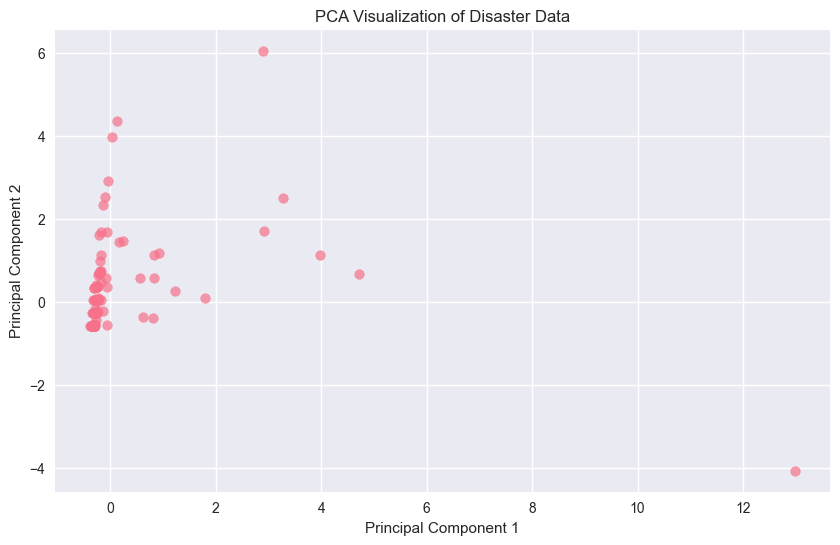

In [13]:
print("\n📉 PCA DIMENSIONALITY REDUCTION")
print("="*50)

# PCA
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    pca.explained_variance_ratio_
)

# Visualisasi PCA
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization of Disaster Data"
)

plt.savefig(
    '../reports/figures/7_pca_visualization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [14]:
print("\n💾 SAVING PROCESSED DATASET")
print("="*50)

# Simpan Dataset
processed_df = pd.DataFrame(
    X_scaled,
    columns=features
)

processed_df.to_csv(
    "../dataset/processed/disaster_prepared.csv",
    index=False
)

# Simpan Sacaler
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

# Simpan PCA
joblib.dump(
    pca,
    "../models/pca.pkl"
)

print("✅ disaster_prepared.csv saved")
print("✅ scaler.pkl saved")
print("✅ pca.pkl saved")


💾 SAVING PROCESSED DATASET
✅ disaster_prepared.csv saved
✅ scaler.pkl saved
✅ pca.pkl saved
